# 01 - Training CNN (Unimodal - Citra Wajah)

**Tujuan:** Melatih model CNN untuk pengenalan emosi menggunakan fitur penampilan dari citra wajah 224x224.

**Menjawab RQ1:** *Bagaimana performa model unimodal CNN dalam pengenalan emosi mahasiswa pada konteks pembelajaran pemrograman menggunakan fitur penampilan dari citra wajah?*

**3 Skenario Imbalance:**
- B1: Tanpa penanganan (baseline)
- B2: Dengan class weights (Cui et al., 2019)
- B3: Dengan class weights + augmentasi

## 1. Setup

In [1]:
import sys
import os
import json
import numpy as np
import torch
import torch.nn as nn
from pathlib import Path

# Add project root to path
PROJECT_ROOT = Path("..").resolve()
sys.path.insert(0, str(PROJECT_ROOT / "src"))

from training.models import EmotionCNN
from training.utils import (
    EmotionImageDataset, get_class_weights,
    train_model, full_evaluation,
    plot_training_history, plot_confusion_matrix, plot_per_class_f1
)

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")
if device.type == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

Device: cuda
GPU: Tesla T4
Memory: 15.6 GB


In [2]:
# Config
DATASET_DIR = PROJECT_ROOT / "data" / "dataset"
DATASET_AUG_DIR = PROJECT_ROOT / "data" / "dataset_augmented"
OUTPUT_DIR = PROJECT_ROOT / "models" / "cnn"
os.makedirs(OUTPUT_DIR, exist_ok=True)

BATCH_SIZE = 32
EPOCHS = 50
LR = 0.0001
PATIENCE = 15
NUM_CLASSES = 7

EMOTIONS = ["neutral", "happy", "sad", "angry", "fearful", "disgusted", "surprised"]
print(f"Dataset: {DATASET_DIR}")
print(f"Output: {OUTPUT_DIR}")

Dataset: /home/bs000716/MOTHER-TANK/TRAIN/data/dataset
Output: /home/bs000716/MOTHER-TANK/TRAIN/models/cnn


## 2. Load Data

In [3]:
from torch.utils.data import DataLoader
from collections import Counter

def load_dataloaders(dataset_dir, batch_size=32):
    """Load train/val/test dataloaders."""
    train_ds = EmotionImageDataset(
        dataset_dir / "X_train_images.npy",
        dataset_dir / "y_train.npy"
    )
    val_ds = EmotionImageDataset(
        dataset_dir / "X_val_images.npy",
        dataset_dir / "y_val.npy"
    )
    test_ds = EmotionImageDataset(
        dataset_dir / "X_test_images.npy",
        dataset_dir / "y_test.npy"
    )

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True)
    val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)
    test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)

    # Print info
    y_train = np.load(dataset_dir / "y_train.npy")
    counts = Counter(y_train.tolist())
    print(f"Train: {len(train_ds)} | Val: {len(val_ds)} | Test: {len(test_ds)}")
    print(f"Train distribution:")
    for i, emo in enumerate(EMOTIONS):
        print(f"  {emo:>10s}: {counts.get(i, 0)}")

    return train_loader, val_loader, test_loader

# Load original dataset
train_loader, val_loader, test_loader = load_dataloaders(DATASET_DIR, BATCH_SIZE)

Train: 7064 | Val: 1174 | Test: 1656
Train distribution:
     neutral: 5678
       happy: 751
         sad: 490
       angry: 48
     fearful: 8
   disgusted: 19
   surprised: 70


## 3. Skenario B1: Baseline (Tanpa Class Weights)

In [4]:
# B1: Baseline - no class weights
model_b1 = EmotionCNN(num_classes=NUM_CLASSES).to(device)
criterion_b1 = nn.CrossEntropyLoss()
optimizer_b1 = torch.optim.Adam(model_b1.parameters(), lr=LR)
scheduler_b1 = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_b1, mode="max", factor=0.5, patience=8, min_lr=1e-7
)

print(f"Model parameters: {sum(p.numel() for p in model_b1.parameters()):,}")
print("Training B1 (baseline)...")
history_b1, best_epoch_b1 = train_model(
    model_b1, train_loader, val_loader, criterion_b1, optimizer_b1, scheduler_b1,
    device, model_type="cnn", epochs=EPOCHS, patience=PATIENCE,
    save_path=str(OUTPUT_DIR / "cnn_b1_baseline.pth")
)

Model parameters: 26,999,463
Training B1 (baseline)...
 Epoch  Train Loss  Train Acc   Val Loss   Val Acc   Val F1         LR
---------------------------------------------------------------------------


     1      1.1193     0.6847     0.5459    0.9284   0.1376   0.000100  (47.9s)


     2      0.6571     0.8153     0.5523    0.9284   0.1376   0.000100  (47.0s)


     3      0.5790     0.8184     0.4315    0.9225   0.1371   0.000100  (46.2s)


     4      0.5386     0.8266     0.4214    0.9267   0.1374   0.000100  (45.9s)


...

    20      0.2669     0.9033     0.6817    0.7479   0.1579   0.000050  (44.6s)


    21      0.2515     0.9128     0.5662    0.7641   0.1525   0.000050  (44.5s)


    22      0.2497     0.9138     0.6273    0.7598   0.1569   0.000050  (44.6s)


    23      0.2413     0.9178     0.5699    0.7768   0.1598   0.000050  (44.5s)


    24      0.2302     0.9163     0.6718    0.7581   0.1619   0.000050  (44.5s)

Early stopping at epoch 24. Best epoch: 9 (val_f1=0.1912)

Best: epoch 9, val_acc=0.8961, val_f1=0.1912
Model saved: /home/bs000716/MOTHER-TANK/TRAIN/models/cnn/cnn_b1_baseline.pth


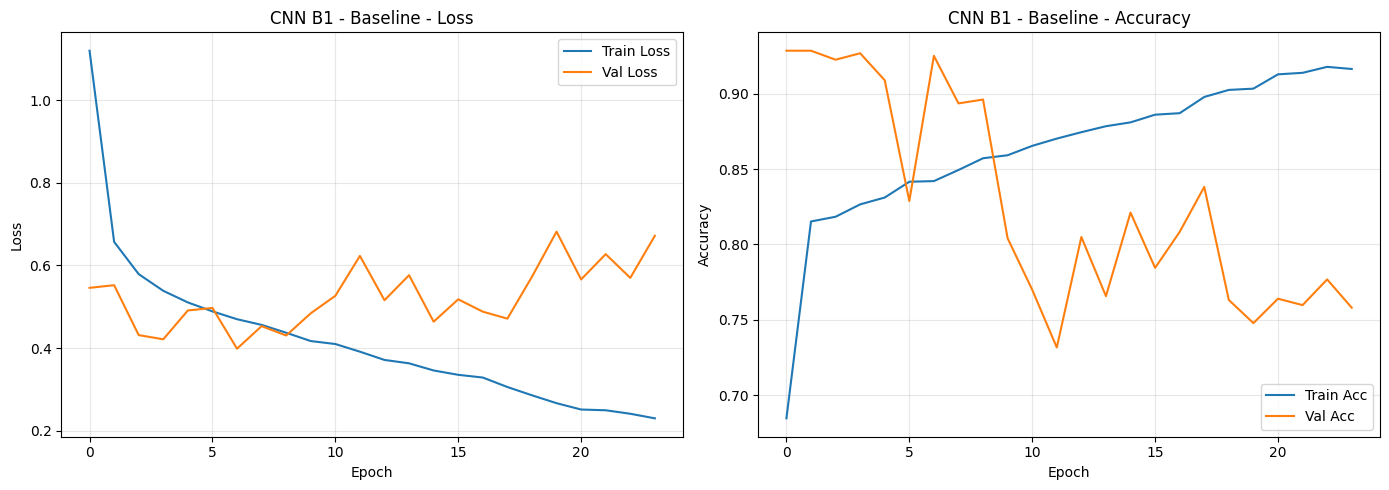

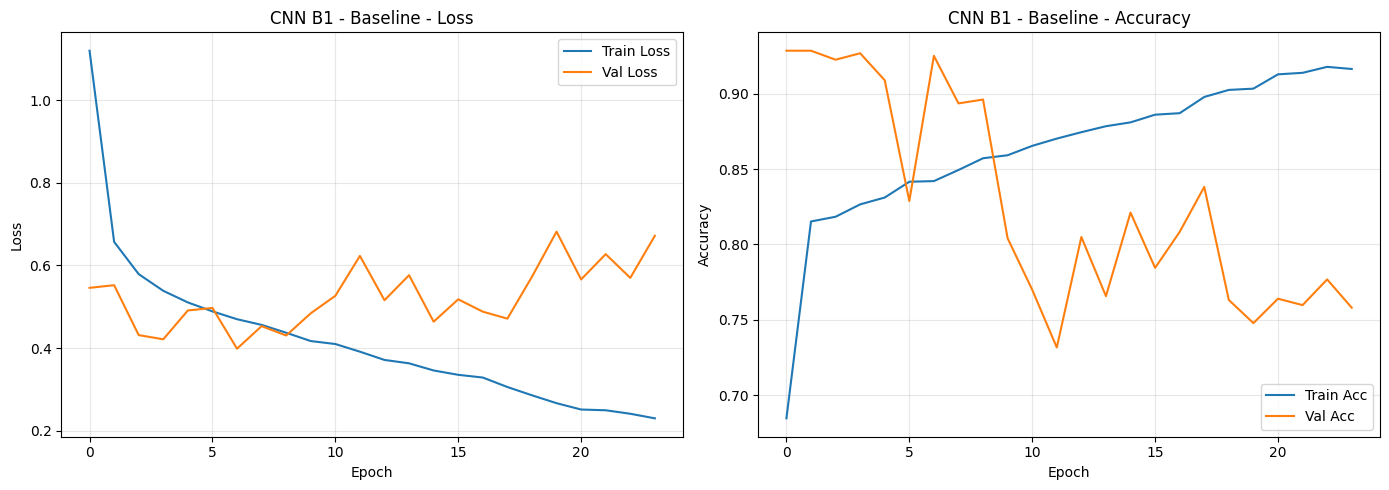

In [5]:
plot_training_history(history_b1, "CNN B1 - Baseline")

EVALUASI B1 - BASELINE


Test Loss: 0.5045
Test Accuracy: 0.8418
Test Macro F1: 0.1329
Test Weighted F1: 0.8814

Classification Report:
              precision    recall  f1-score   support

     neutral       0.96      0.88      0.92      1588
       happy       0.00      0.00      0.00        10
         sad       0.01      0.03      0.01        38
       angry       0.00      0.00      0.00        13
     fearful       0.00      0.00      0.00         1
   disgusted       0.00      0.00      0.00         3
   surprised       0.00      0.00      0.00         3

    accuracy                           0.84      1656
   macro avg       0.14      0.13      0.13      1656
weighted avg       0.93      0.84      0.88      1656



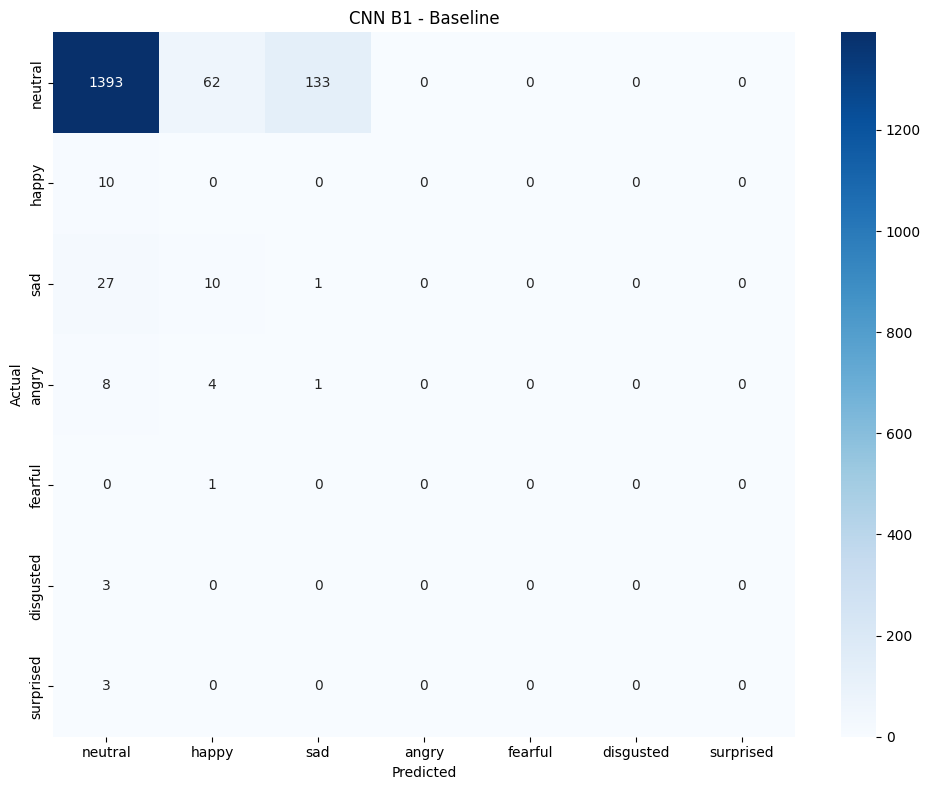

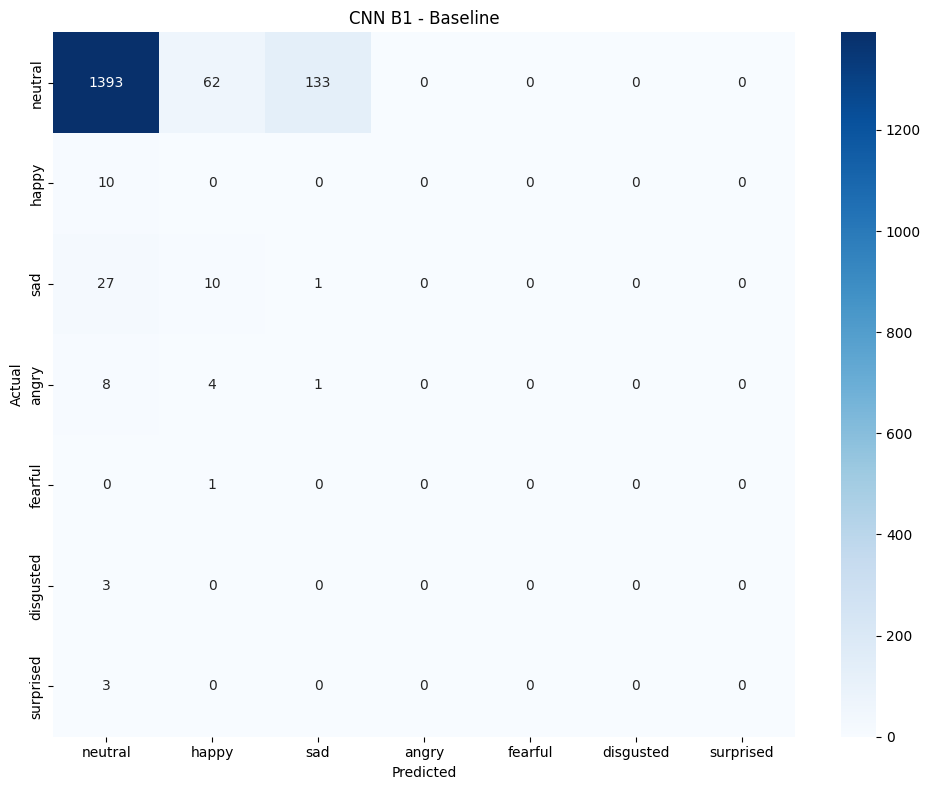

In [6]:
# Evaluate B1 on test set
print("=" * 60)
print("EVALUASI B1 - BASELINE")
print("=" * 60)
results_b1 = full_evaluation(model_b1, test_loader, criterion_b1, device, "cnn")
plot_confusion_matrix(results_b1["confusion_matrix"], "CNN B1 - Baseline")

## 4. Skenario B2: Dengan Class Weights

In [7]:
# B2: With class weights (Cui et al., 2019)
weights = get_class_weights(DATASET_DIR, device)
print(f"Class weights: {weights}")

model_b2 = EmotionCNN(num_classes=NUM_CLASSES).to(device)
criterion_b2 = nn.CrossEntropyLoss(weight=weights)
optimizer_b2 = torch.optim.Adam(model_b2.parameters(), lr=LR)
scheduler_b2 = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_b2, mode="max", factor=0.5, patience=8, min_lr=1e-7
)

print("\nTraining B2 (class weights)...")
history_b2, best_epoch_b2 = train_model(
    model_b2, train_loader, val_loader, criterion_b2, optimizer_b2, scheduler_b2,
    device, model_type="cnn", epochs=EPOCHS, patience=PATIENCE,
    save_path=str(OUTPUT_DIR / "cnn_b2_weighted.pth")
)

Class weights: tensor([  1.0000,   1.8865,   2.5717,  21.2542, 125.0103,  52.9257,  14.7340],
       device='cuda:0')



Training B2 (class weights)...
 Epoch  Train Loss  Train Acc   Val Loss   Val Acc   Val F1         LR
---------------------------------------------------------------------------


     1      1.6484     0.4993     1.2053    0.9284   0.1376   0.000100  (44.4s)


     2      1.3401     0.7525     1.0628    0.9293   0.1435   0.000100  (44.6s)


     3      1.2594     0.7793     1.1403    0.9225   0.1378   0.000100  (44.7s)


...

    34      0.3320     0.8982     1.0457    0.8671   0.1857   0.000050  (45.0s)


    35      0.3065     0.8996     1.0912    0.8620   0.1858   0.000050  (44.8s)


    36      0.2892     0.9043     1.0835    0.8433   0.1840   0.000050  (44.9s)


    37      0.2965     0.9052     1.0815    0.8807   0.1910   0.000050  (44.9s)


    38      0.2756     0.9049     1.1497    0.8526   0.1818   0.000050  (44.8s)

Early stopping at epoch 38. Best epoch: 23 (val_f1=0.2643)

Best: epoch 23, val_acc=0.8893, val_f1=0.2643
Model saved: /home/bs000716/MOTHER-TANK/TRAIN/models/cnn/cnn_b2_weighted.pth


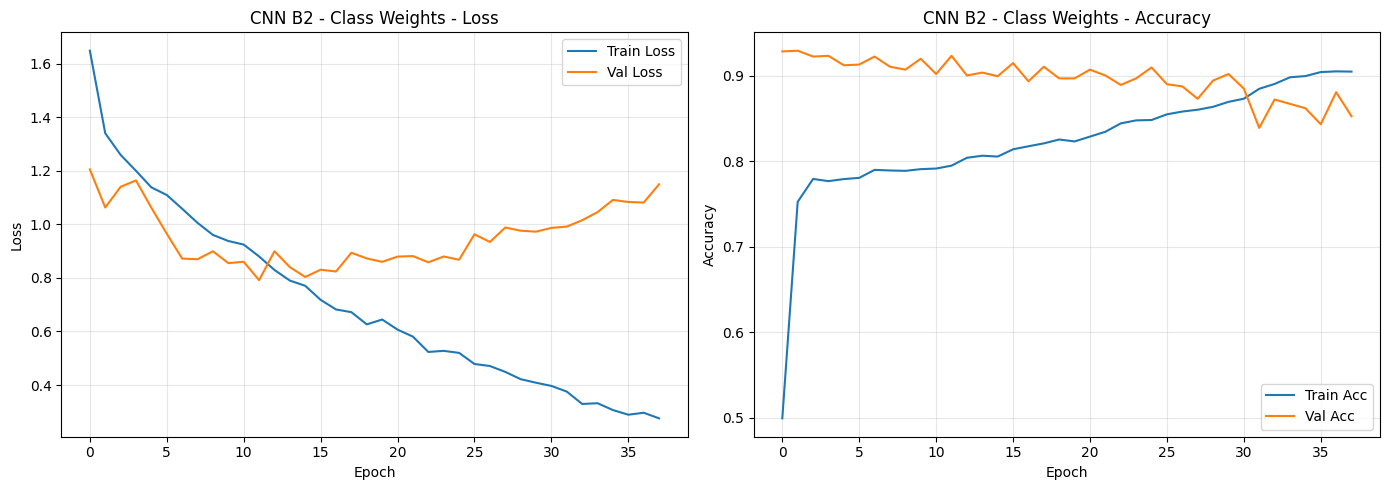

EVALUASI B2 - CLASS WEIGHTS


Test Loss: 1.0167
Test Accuracy: 0.8279
Test Macro F1: 0.1335
Test Weighted F1: 0.8720

Classification Report:
              precision    recall  f1-score   support

     neutral       0.96      0.86      0.91      1588
       happy       0.00      0.00      0.00        10
         sad       0.02      0.05      0.03        38
       angry       0.00      0.00      0.00        13
     fearful       0.00      0.00      0.00         1
   disgusted       0.00      0.00      0.00         3
   surprised       0.00      0.00      0.00         3

    accuracy                           0.83      1656
   macro avg       0.14      0.13      0.13      1656
weighted avg       0.92      0.83      0.87      1656



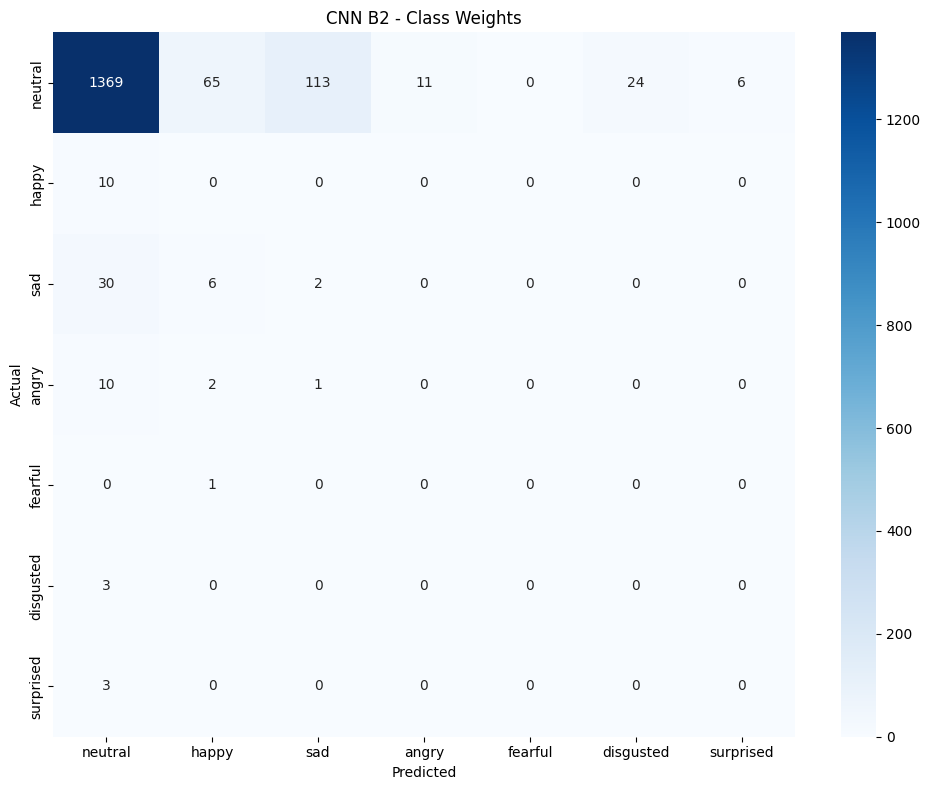

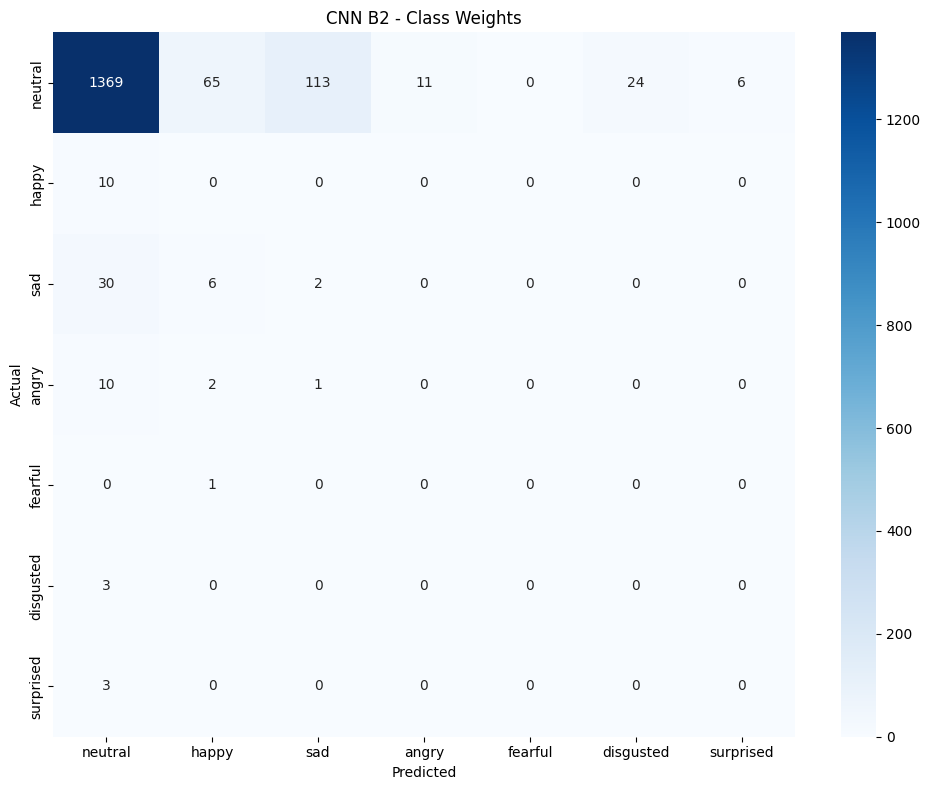

In [8]:
plot_training_history(history_b2, "CNN B2 - Class Weights")

print("=" * 60)
print("EVALUASI B2 - CLASS WEIGHTS")
print("=" * 60)
results_b2 = full_evaluation(model_b2, test_loader, criterion_b2, device, "cnn")
plot_confusion_matrix(results_b2["confusion_matrix"], "CNN B2 - Class Weights")

## 5. Skenario B3: Class Weights + Augmentasi

In [9]:
# B3: Class weights + augmented data
train_loader_aug, _, _ = load_dataloaders(DATASET_AUG_DIR, BATCH_SIZE)
weights_aug = get_class_weights(DATASET_AUG_DIR, device)
print(f"Augmented class weights: {weights_aug}")

model_b3 = EmotionCNN(num_classes=NUM_CLASSES).to(device)
criterion_b3 = nn.CrossEntropyLoss(weight=weights_aug)
optimizer_b3 = torch.optim.Adam(model_b3.parameters(), lr=LR)
scheduler_b3 = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_b3, mode="max", factor=0.5, patience=8, min_lr=1e-7
)

print("\nTraining B3 (class weights + augmentation)...")
history_b3, best_epoch_b3 = train_model(
    model_b3, train_loader_aug, val_loader, criterion_b3, optimizer_b3, scheduler_b3,
    device, model_type="cnn", epochs=EPOCHS, patience=PATIENCE,
    save_path=str(OUTPUT_DIR / "cnn_b3_augmented.pth")
)

Train: 7519 | Val: 1174 | Test: 1656
Train distribution:
     neutral: 5678
       happy: 751
         sad: 490
       angry: 150
     fearful: 150
   disgusted: 150
   surprised: 150
Augmented class weights: tensor([1.0000, 1.8865, 2.5717, 7.1514, 7.1514, 7.1514, 7.1514],
       device='cuda:0')



Training B3 (class weights + augmentation)...
 Epoch  Train Loss  Train Acc   Val Loss   Val Acc   Val F1         LR
---------------------------------------------------------------------------


     1      1.5916     0.5545     1.2045    0.9148   0.1366   0.000100  (49.4s)


     2      1.2971     0.7236     1.0378    0.9003   0.1354   0.000100  (49.8s)


     3      1.1280     0.7417     1.0253    0.8637   0.1329   0.000100  (49.6s)


...

    26      0.2578     0.9074     0.9977    0.7768   0.1488   0.000050  (48.6s)


    27      0.2297     0.9189     0.9480    0.8271   0.1550   0.000050  (48.8s)


    28      0.2342     0.9138     1.0619    0.7572   0.1478   0.000050  (48.4s)


    29      0.2295     0.9157     0.9739    0.8424   0.1583   0.000050  (48.7s)


    30      0.2138     0.9181     1.0243    0.7973   0.1504   0.000050  (48.7s)

Early stopping at epoch 30. Best epoch: 15 (val_f1=0.1904)

Best: epoch 15, val_acc=0.8782, val_f1=0.1904
Model saved: /home/bs000716/MOTHER-TANK/TRAIN/models/cnn/cnn_b3_augmented.pth


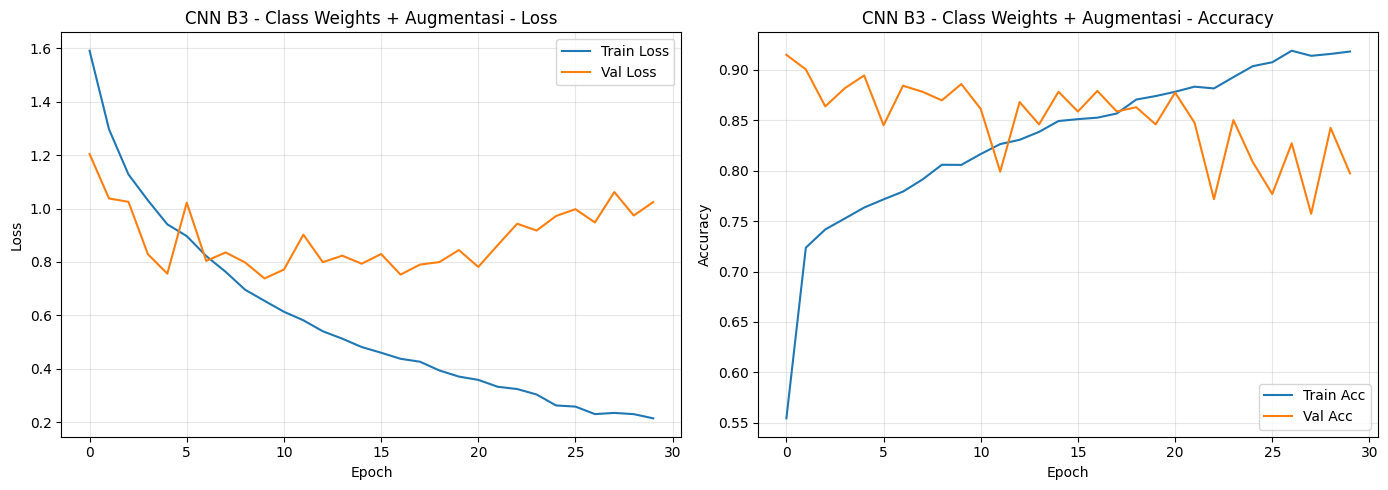

EVALUASI B3 - CLASS WEIGHTS + AUGMENTASI


Test Loss: 1.0509
Test Accuracy: 0.6486
Test Macro F1: 0.1194
Test Weighted F1: 0.7659

Classification Report:
              precision    recall  f1-score   support

     neutral       0.98      0.67      0.80      1588
       happy       0.00      0.00      0.00        10
         sad       0.03      0.08      0.04        38
       angry       0.00      0.00      0.00        13
     fearful       0.00      0.00      0.00         1
   disgusted       0.00      0.00      0.00         3
   surprised       0.00      0.00      0.00         3

    accuracy                           0.65      1656
   macro avg       0.14      0.11      0.12      1656
weighted avg       0.94      0.65      0.77      1656



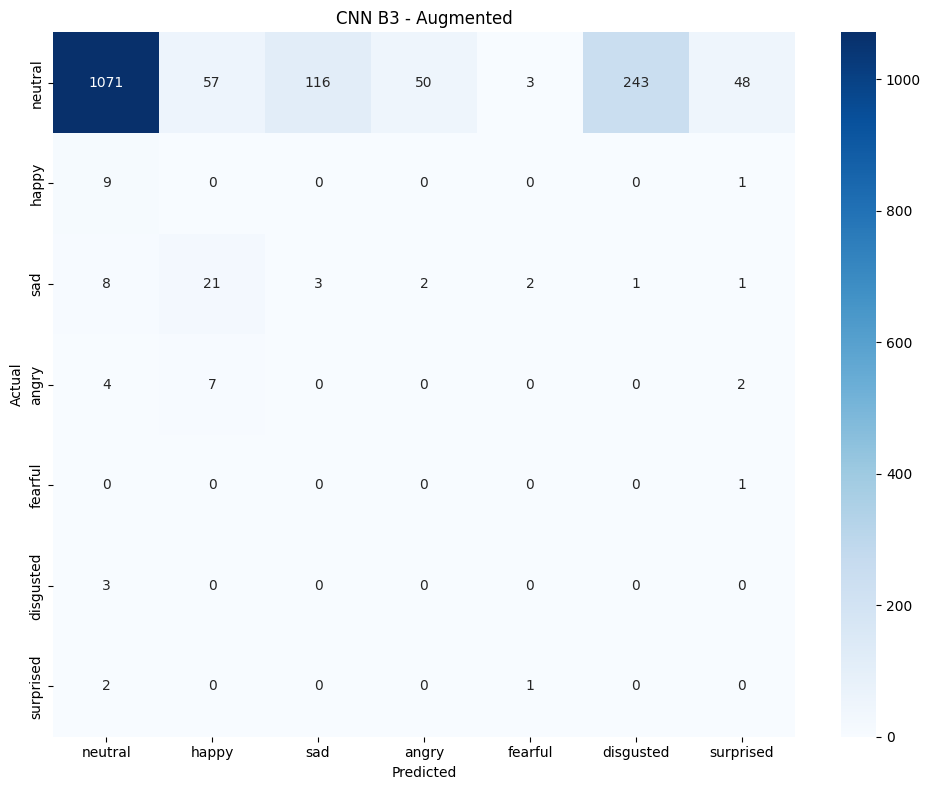

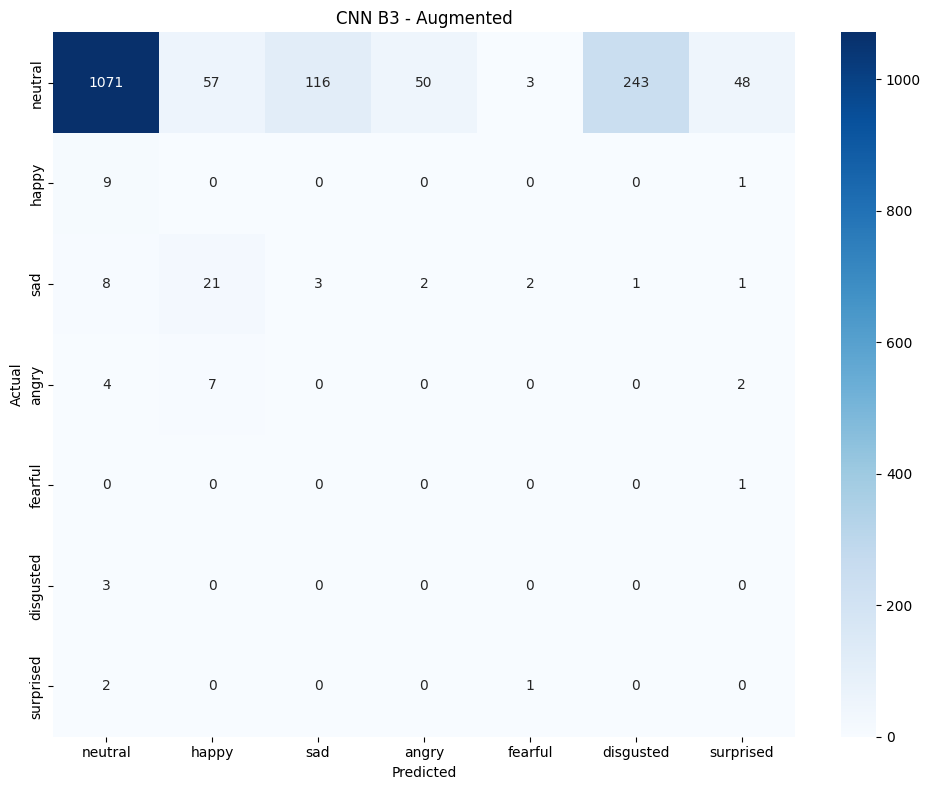

In [10]:
plot_training_history(history_b3, "CNN B3 - Class Weights + Augmentasi")

print("=" * 60)
print("EVALUASI B3 - CLASS WEIGHTS + AUGMENTASI")
print("=" * 60)
results_b3 = full_evaluation(model_b3, test_loader, criterion_b3, device, "cnn")
plot_confusion_matrix(results_b3["confusion_matrix"], "CNN B3 - Augmented")

## 6. Perbandingan 3 Skenario

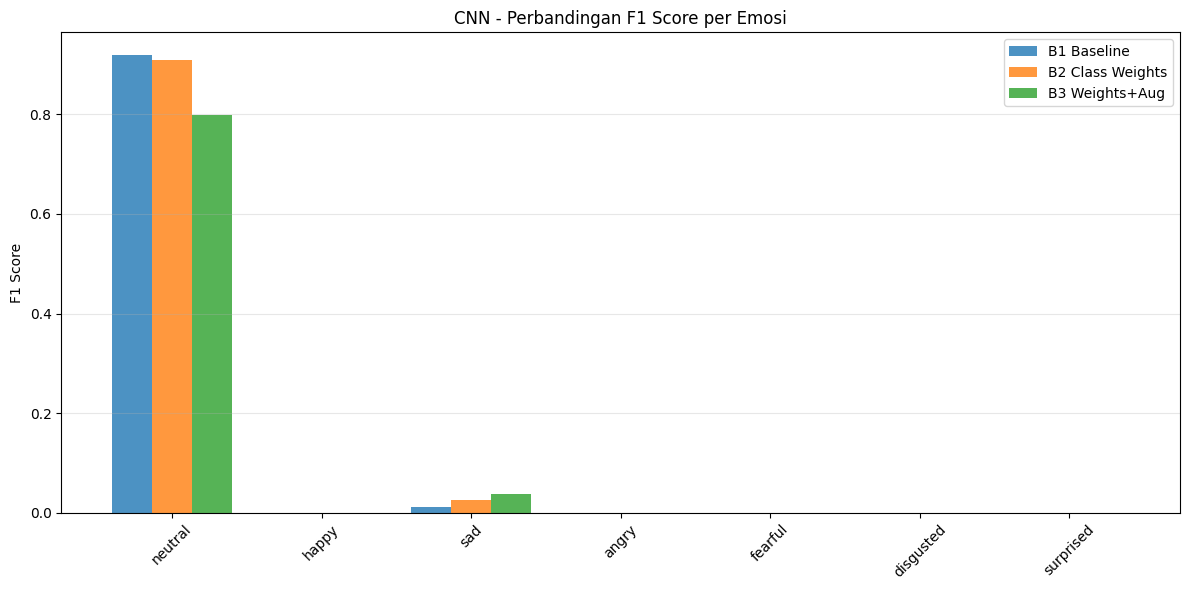

RINGKASAN CNN - 3 SKENARIO
Skenario                    Accuracy   Macro F1  Weighted F1
----------------------------------------------------------------------
B1 Baseline                   0.8418     0.1329       0.8814
B2 Class Weights              0.8279     0.1335       0.8720
B3 Weights+Aug                0.6486     0.1194       0.7659

Results saved to /home/bs000716/MOTHER-TANK/TRAIN/models/cnn/cnn_results.json


In [11]:
# Perbandingan per-class F1 score
all_results = {
    "B1 Baseline": results_b1,
    "B2 Class Weights": results_b2,
    "B3 Weights+Aug": results_b3,
}
plot_per_class_f1(all_results, "CNN - Perbandingan F1 Score per Emosi")

# Summary table
print("=" * 70)
print("RINGKASAN CNN - 3 SKENARIO")
print("=" * 70)
print(f"{'Skenario':<25} {'Accuracy':>10} {'Macro F1':>10} {'Weighted F1':>12}")
print("-" * 70)
for name, r in all_results.items():
    print(f"{name:<25} {r['test_accuracy']:>10.4f} {r['test_macro_f1']:>10.4f} {r['test_weighted_f1']:>12.4f}")

# Save results
cnn_results = {}
for name, r in all_results.items():
    cnn_results[name] = {
        "accuracy": float(r["test_accuracy"]),
        "macro_f1": float(r["test_macro_f1"]),
        "weighted_f1": float(r["test_weighted_f1"]),
    }
with open(OUTPUT_DIR / "cnn_results.json", "w") as f:
    json.dump(cnn_results, f, indent=2)
print(f"\nResults saved to {OUTPUT_DIR / 'cnn_results.json'}")